In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [22]:
customers_df = pd.read_csv("C:/Users/shanz/Downloads/customers-1.csv")
products_df = pd.read_csv("C:/Users/shanz/Downloads/products.csv")
sales_df = pd.read_csv("C:/Users/shanz/Downloads/sales.csv")

In [23]:
customers_df.head()

,customer_id,first_name,last_name,age,state,income,registration_date,email
0,1,John,Smith,34,CA,75000,2022-01-15,john.smith@email.com
1,2,Sarah,Johnson,28,NY,82000,2022-01-22,sarah.johnson@email.com
2,3,Michael,Brown,45,TX,95000,2022-02-03,michael.brown@email.com
3,4,Emily,Davis,31,FL,68000,2022-02-14,emily.davis@email.com
4,5,David,Wilson,52,IL,110000,2022-02-28,david.wilson@email.com


In [24]:
products_df.head()

,product_id,product_name,category,price,launch_date,brand
0,1,Wireless Bluetooth Headphones,Electronics,79.99,2021-03-15,AudioTech
1,2,Organic Cotton T-Shirt,Clothing,24.99,2021-04-20,EcoWear
2,3,Stainless Steel Water Bottle,Home & Garden,19.99,2021-05-10,HydroLife
3,4,Leather Crossbody Bag,Accessories,89.99,2021-06-01,StyleCraft
4,5,Yoga Mat Premium,Sports & Outdoors,34.99,2021-06-15,FitZone


In [25]:
sales_df.head()

,sale_id,customer_id,product_id,transaction_date,quantity,total_amount
0,1,1,1,2022-02-10 14:30:00,1,79.99
1,2,2,3,2022-02-15 10:15:00,2,39.98
2,3,3,5,2022-02-20 16:45:00,1,34.99
3,4,4,2,2022-02-25 11:20:00,3,74.97
4,5,5,4,2022-03-01 13:10:00,1,89.99


In [29]:
sales_with_prices = pd.merge(sales_df, products_df, on= 'product_id')
sales_with_prices['revenue']= sales_with_prices['price'] * sales_with_prices['quantity']
category_revenue = sales_with_prices.groupby('category')['revenue'].sum().sort_values(ascending=False).reset_index()

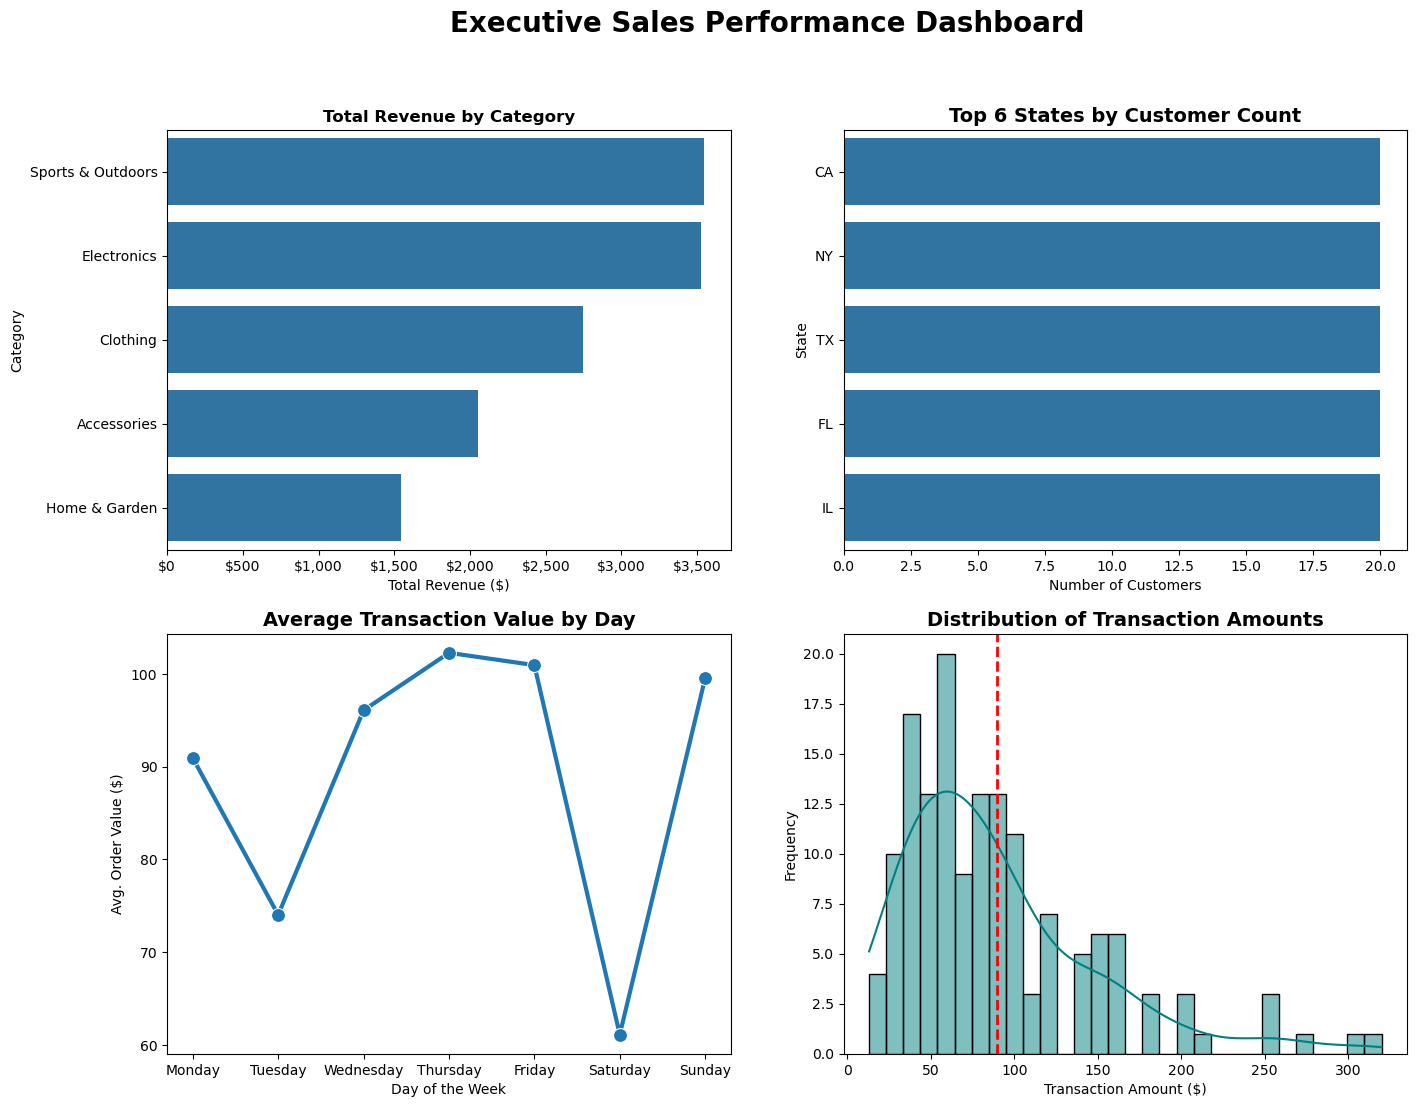

In [69]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Executive Sales Performance Dashboard', fontsize=20, fontweight='bold')
sns.barplot(data=category_revenue, x='revenue', y='category', ax=ax1)
ax1.set_title('Total Revenue by Category', fontweight= 'bold')
ax1.set_xlabel('Total Revenue ($)')
ax1.set_ylabel('Category')
fmt = '${x:,.0f}'
tick = mtick.StrMethodFormatter(fmt)
ax1.xaxis.set_major_formatter(tick)

state_counts= customers_df['state'].value_counts().reset_index()
state_counts.columns = ['state', 'customer_count']
top_6_states = state_counts.head(6)

sns.barplot(data=top_6_states, x='customer_count', y='state', ax=ax2)
ax2.set_title('Top 6 States by Customer Count', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Customers')
ax2.set_ylabel('State')

sales_df['transaction_date'] = pd.to_datetime(sales_df['transaction_date'])
sales_df['day_of_week'] = sales_df['transaction_date'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_daily_sales = sales_df.groupby('day_of_week')['total_amount'].mean().reindex(days_order).reset_index()

sns.lineplot(
    data=avg_daily_sales, 
    x='day_of_week', 
    y='total_amount', 
    marker='o',         # Adds the "dots" on each day
    markersize=10, 
    linewidth=3, 
    ax=ax3)
ax3.set_title('Average Transaction Value by Day', fontsize=14, fontweight='bold')
ax3.set_xlabel('Day of the Week')
ax3.set_ylabel('Avg. Order Value ($)')


mean_val = sales_df['total_amount'].mean()
sns.histplot(
    data=sales_df, 
    x='total_amount', 
    bins=30,            
    kde=True,           
    color='teal', 
    ax=ax4)

#Add the Mean Reference Line
ax4.axvline(mean_val, 
    color='red', 
    linestyle='--',     # Makes the line dashed
    linewidth=2, 
    label=f'Mean: ${mean_val:,.2f}')
ax4.set_title('Distribution of Transaction Amounts', fontsize=14, fontweight='bold')
ax4.set_xlabel('Transaction Amount ($)')
ax4.set_ylabel('Frequency')
plt.show()

state
CA    20
NY    20
TX    20
FL    20
IL    20
Name: count, dtype: int64


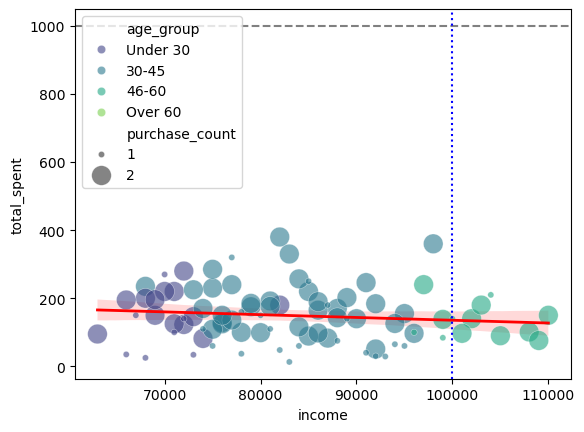

In [82]:
customer_spend= pd.merge(sales_df, customers_df, on='customer_id')
customer_summary= customer_spend.groupby(['customer_id', 'age', 'income']).agg(
    total_spent=('total_amount', 'sum'),
    purchase_count=('total_amount', 'count')).reset_index()
bins = [0, 30, 45, 60, 100]
labels = ['Under 30', '30-45', '46-60', 'Over 60']
customer_summary['age_group'] = pd.cut(customer_summary['age'], bins=bins, labels=labels)

# LAYER 1 & 2: Scatter Plot + Regression Line
ax = sns.regplot(data=customer_summary, x='income', y='total_spent', 
                 scatter=False, color='black', line_kws={"color": "red", "lw": 2})
sns.scatterplot(data=customer_summary, x='income', y='total_spent', 
                hue='age_group', size='purchase_count', alpha=0.6, 
                palette='viridis', sizes=(20, 200))
# LAYER 3: Business Context References
plt.axhline(y=1000, color='gray', linestyle='--', label='Target Spending ($1k)')
plt.axvline(x=100000, color='blue', linestyle=':', label='High Income Threshold ($100k)')